# Оценка вероятности того, что пациент выживет


## 2. Подготовка данных

## 1. Импорт библиотек

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
import category_encoders as ce
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
print('Библиотеки загружены.')

Библиотеки загружены.


## 2. Загрузка данных

In [2]:
df = pd.read_csv('dataset.csv')

print(f'Загружено: {df.shape[0]:,} строк, {df.shape[1]} столбцов')
print(f'Смертность: {df["hospital_death"].mean()*100:.1f}%')

Загружено: 91,713 строк, 85 столбцов
Смертность: 8.6%


## 3. Удаление лишних столбцов

In [3]:
TARGET = 'hospital_death'

# Идентификаторы — не несут предсказательной силы
id_cols = ['encounter_id', 'patient_id', 'hospital_id', 'icu_id']

# Утечка данных — готовые предсказания системы APACHE IV
leakage_cols = ['apache_4a_hospital_death_prob', 'apache_4a_icu_death_prob']

# Технический мусор
junk_cols = ['Unnamed: 83']

drop_cols = [c for c in id_cols + leakage_cols + junk_cols if c in df.columns]
df.drop(columns=drop_cols, inplace=True)

print(f'Удалено {len(drop_cols)} столбцов:')
for c in drop_cols:
    print(f'  - {c}')
print(f'Осталось столбцов: {df.shape[1]} (включая таргет)')

Удалено 7 столбцов:
  - encounter_id
  - patient_id
  - hospital_id
  - icu_id
  - apache_4a_hospital_death_prob
  - apache_4a_icu_death_prob
  - Unnamed: 83
Осталось столбцов: 78 (включая таргет)


## 4. Определение типов признаков

In [4]:
# Категориальные столбцы
CAT_COLS = [
    'ethnicity', 'gender', 'icu_admit_source', 'icu_stay_type',
    'icu_type', 'apache_3j_bodysystem', 'apache_2_bodysystem'
]
CAT_COLS = [c for c in CAT_COLS if c in df.columns]

# Бинарные флаги (0/1)
BIN_COLS = [
    'elective_surgery', 'apache_post_operative', 'arf_apache',
    'gcs_unable_apache', 'intubated_apache', 'ventilated_apache',
    'aids', 'cirrhosis', 'diabetes_mellitus', 'hepatic_failure',
    'immunosuppression', 'leukemia', 'lymphoma', 'solid_tumor_with_metastasis'
]
BIN_COLS = [c for c in BIN_COLS if c in df.columns]

# Числовые непрерывные
NUM_COLS = [
    c for c in df.columns
    if c not in CAT_COLS + BIN_COLS + [TARGET]
    and df[c].dtype in ['float64', 'int64']
]

print(f'Категориальных:  {len(CAT_COLS)}')
print(f'Бинарных:        {len(BIN_COLS)}')
print(f'Числовых:        {len(NUM_COLS)}')
print(f'Категориальные столбцы: {CAT_COLS}')

Категориальных:  7
Бинарных:        14
Числовых:        56
Категориальные столбцы: ['ethnicity', 'gender', 'icu_admit_source', 'icu_stay_type', 'icu_type', 'apache_3j_bodysystem', 'apache_2_bodysystem']


## 5. Заполнение пропусков + флаги пропусков

In [5]:
missing_before = df.isnull().sum()
missing_before = missing_before[missing_before > 0].sort_values(ascending=False)
print(f'Столбцов с пропусками: {len(missing_before)}')
print('Топ-10:')
print((missing_before.head(10) / len(df) * 100).round(2).astype(str) + '%')

Столбцов с пропусками: 72
Топ-10:
d1_potassium_max             10.45%
d1_potassium_min             10.45%
h1_mbp_noninvasive_min         9.9%
h1_mbp_noninvasive_max         9.9%
h1_diasbp_noninvasive_min     8.01%
h1_diasbp_noninvasive_max     8.01%
h1_sysbp_noninvasive_min       8.0%
h1_sysbp_noninvasive_max       8.0%
d1_glucose_min                6.33%
d1_glucose_max                6.33%
dtype: object


In [6]:
# Флаги пропусков для числовых столбцов с >1% пропусков
FLAG_THRESHOLD = 0.01
flag_cols = [c for c in NUM_COLS if df[c].isnull().mean() > FLAG_THRESHOLD]

for col in flag_cols:
    df[f'{col}_was_missing'] = df[col].isnull().astype(int)

new_flag_cols = [f'{c}_was_missing' for c in flag_cols]
BIN_COLS = BIN_COLS + new_flag_cols

print(f'Добавлено флагов пропусков: {len(flag_cols)}')
print(f'Примеры: {new_flag_cols[:5]}')

Добавлено флагов пропусков: 42
Примеры: ['age_was_missing', 'bmi_was_missing', 'height_was_missing', 'weight_was_missing', 'apache_2_diagnosis_was_missing']


In [7]:
# Числовые — медианой
for col in NUM_COLS:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].median())

# Категориальные — модой
for col in CAT_COLS:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].mode()[0])

# Бинарные — нулём
for col in BIN_COLS:
    if col in df.columns and df[col].isnull().any():
        df[col] = df[col].fillna(0)

print(f'Пропусков после заполнения: {df.isnull().sum().sum()}')

Пропусков после заполнения: 0


## 6. Клиппинг выбросов по клиническим границам

In [8]:
clinical_bounds = {
    'age':              (0,   130),
    'bmi':              (10,  100),
    'height':           (100, 250),
    'weight':           (20,  400),
    'd1_heartrate_max': (10,  300),
    'd1_heartrate_min': (10,  300),
    'h1_heartrate_max': (10,  300),
    'h1_heartrate_min': (10,  300),
    'heart_rate_apache': (10, 300),
    'd1_sysbp_max':     (40,  300),
    'd1_sysbp_min':     (40,  300),
    'h1_sysbp_max':     (40,  300),
    'h1_sysbp_min':     (40,  300),
    'd1_sysbp_noninvasive_max': (40, 300),
    'd1_sysbp_noninvasive_min': (40, 300),
    'h1_sysbp_noninvasive_max': (40, 300),
    'h1_sysbp_noninvasive_min': (40, 300),
    'd1_diasbp_max':    (20,  200),
    'd1_diasbp_min':    (20,  200),
    'h1_diasbp_max':    (20,  200),
    'h1_diasbp_min':    (20,  200),
    'd1_mbp_max':       (20,  250),
    'd1_mbp_min':       (20,  250),
    'h1_mbp_max':       (20,  250),
    'h1_mbp_min':       (20,  250),
    'map_apache':       (20,  250),
    'd1_temp_max':      (25,  45),
    'd1_temp_min':      (25,  45),
    'temp_apache':      (25,  45),
    'd1_spo2_max':      (50,  100),
    'd1_spo2_min':      (50,  100),
    'h1_spo2_max':      (50,  100),
    'h1_spo2_min':      (50,  100),
    'd1_resprate_max':  (4,   80),
    'd1_resprate_min':  (4,   80),
    'h1_resprate_max':  (4,   80),
    'h1_resprate_min':  (4,   80),
    'resprate_apache':  (4,   80),
    'd1_glucose_max':   (20,  1500),
    'd1_glucose_min':   (20,  1500),
    'd1_potassium_max': (1.5, 10),
    'd1_potassium_min': (1.5, 10),
}

clipped_stats = []
for col, (low, high) in clinical_bounds.items():
    if col in df.columns:
        n_below = (df[col] < low).sum()
        n_above = (df[col] > high).sum()
        if n_below > 0 or n_above > 0:
            df[col] = df[col].clip(lower=low, upper=high)
            clipped_stats.append({
                'Столбец': col,
                'Обрезано снизу': n_below,
                'Обрезано сверху': n_above
            })

if clipped_stats:
    print('Столбцы с обрезанными значениями:')
    display(pd.DataFrame(clipped_stats).set_index('Столбец'))
else:
    print('Клинически невозможных значений не обнаружено.')

Столбцы с обрезанными значениями:


,Обрезано снизу,Обрезано сверху
Столбец,,
d1_heartrate_min,652,0
d1_diasbp_min,1329,0
d1_spo2_max,12,0
d1_spo2_min,1116,0
h1_spo2_max,47,0
h1_spo2_min,315,0
d1_resprate_max,0,737
d1_resprate_min,4516,2
h1_resprate_min,771,21


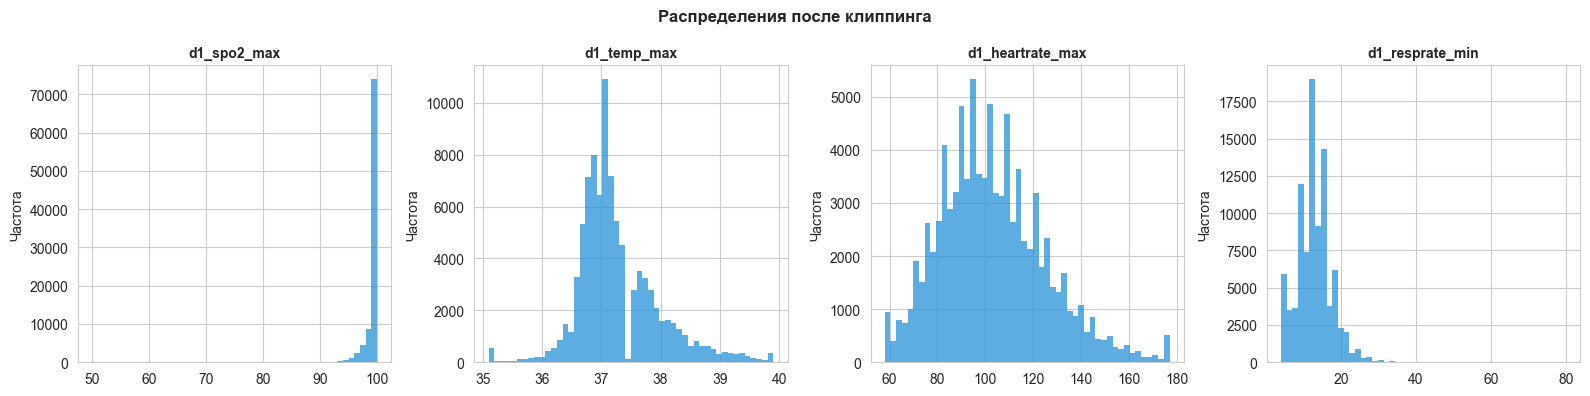

In [9]:
# Распределения после клиппинга
check_cols = ['d1_spo2_max', 'd1_temp_max', 'd1_heartrate_max', 'd1_resprate_min']
check_cols = [c for c in check_cols if c in df.columns]

fig, axes = plt.subplots(1, len(check_cols), figsize=(16, 4))
for ax, col in zip(axes, check_cols):
    ax.hist(df[col].dropna(), bins=50, color='#3498db', edgecolor='none', alpha=0.8)
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.set_ylabel('Частота')
plt.suptitle('Распределения после клиппинга', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Train/Test split

In [10]:
X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'Train: {X_train.shape[0]:,} строк,  Test: {X_test.shape[0]:,} строк')
print(f'Смертность train: {y_train.mean()*100:.2f}%')
print(f'Смертность test:  {y_test.mean()*100:.2f}%')

Train: 73,370 строк,  Test: 18,343 строк
Смертность train: 8.63%
Смертность test:  8.63%


## 8. Масштабирование числовых признаков (RobustScaler)

**RobustScaler** использует медиану и IQR - устойчив к остаточным выбросам.  
Обучаем **только на train**, применяем на train и test.

In [11]:
scaler = RobustScaler()
num_cols_in_X = [c for c in NUM_COLS if c in X_train.columns]

X_train = X_train.copy()
X_test  = X_test.copy()

X_train[num_cols_in_X] = scaler.fit_transform(X_train[num_cols_in_X])
X_test[num_cols_in_X]  = scaler.transform(X_test[num_cols_in_X])

print(f'Масштабировано числовых признаков: {len(num_cols_in_X)}')
print('Среднее после масштабирования (первые 5, близко к 0):')
print(X_train[num_cols_in_X[:5]].mean().round(3))

Масштабировано числовых признаков: 56
Среднее после масштабирования (первые 5, близко к 0):
age                -0.116
bmi                 0.165
height             -0.032
pre_icu_los_days    1.870
weight              0.123
dtype: float64


## 9. Кодирование категориальных признаков

### Схема 1 - WoE (Weight of Evidence)

Каждая категория заменяется значением:
$$WoE_i = \ln\left(\frac{P(X=i \mid Y=1)}{P(X=i \mid Y=0)}\right)$$

WoE > 0 - категория чаще встречается у **умерших**, WoE < 0 - у **выживших**.  

In [12]:
cat_cols_in_X = [c for c in CAT_COLS if c in X_train.columns]

woe_encoder = ce.WOEEncoder(cols=cat_cols_in_X, regularization=1.0)

X_train_woe = X_train.copy()
X_test_woe  = X_test.copy()

X_train_woe[cat_cols_in_X] = woe_encoder.fit_transform(X_train[cat_cols_in_X], y_train)
X_test_woe[cat_cols_in_X]  = woe_encoder.transform(X_test[cat_cols_in_X])

print('WoE-кодирование применено.')

# Таблица WoE-значений по всем категориальным столбцам
woe_summary = {}
for col in cat_cols_in_X:
    woe_map = pd.DataFrame({
        'Категория': X_train[col],
        'WoE':       X_train_woe[col]
    }).groupby('Категория')['WoE'].mean().round(4)
    woe_summary[col] = woe_map

print('\nWoE-значения по категориям:')
for col, woe_map in woe_summary.items():
    print(f'\n  {col}:')
    print(woe_map.sort_values().to_string())

WoE-кодирование применено.

WoE-значения по категориям:

  ethnicity:
Категория
African American   -0.1188
Other/Unknown      -0.0818
Caucasian           0.0120
Asian               0.0300
Hispanic            0.1176
Native American     0.1329

  gender:
Категория
M   -0.0261
F    0.0298

  icu_admit_source:
Категория
Operating Room / Recovery   -0.8836
Accident & Emergency        -0.0043
Other Hospital               0.4857
Floor                        0.5072
Other ICU                    0.5342

  icu_stay_type:
Категория
admit      -0.0165
readmit     0.1347
transfer    0.2413

  icu_type:
Категория
CSICU          -0.5091
CTICU          -0.3957
CCU-CTICU      -0.1855
SICU           -0.1506
Neuro ICU      -0.0331
Med-Surg ICU    0.0217
Cardiac ICU     0.1627
MICU            0.3987

  apache_3j_bodysystem:
Категория
Gynecological          -2.0514
Metabolic              -1.8653
Musculoskeletal/Skin   -0.5607
Genitourinary          -0.3090
Trauma                 -0.2783
Gastrointestinal    

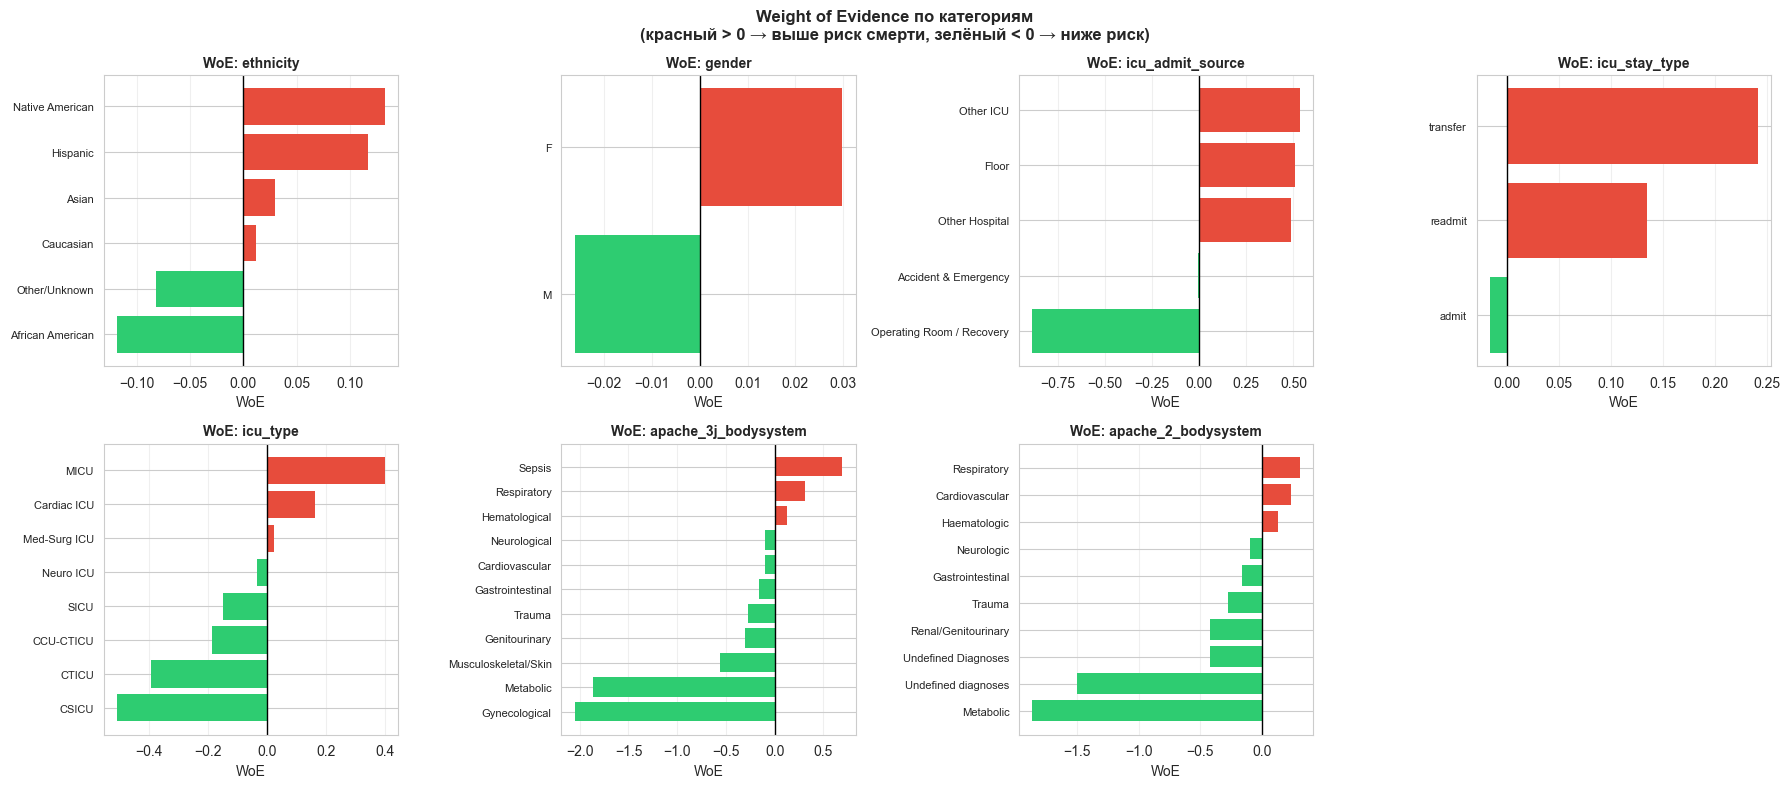

In [13]:
# Визуализация WoE
n_cat = len(cat_cols_in_X)
n_cols_plot = min(4, n_cat)
n_rows_plot = (n_cat + n_cols_plot - 1) // n_cols_plot

fig, axes = plt.subplots(n_rows_plot, n_cols_plot, figsize=(18, n_rows_plot * 4))
axes = np.array(axes).flatten()

for idx, col in enumerate(cat_cols_in_X):
    ax = axes[idx]
    woe_map = woe_summary[col].sort_values()
    colors = ['#e74c3c' if v > 0 else '#2ecc71' for v in woe_map.values]
    ax.barh(woe_map.index.astype(str), woe_map.values, color=colors, edgecolor='none')
    ax.axvline(0, color='black', linewidth=1)
    ax.set_title(f'WoE: {col}', fontsize=10, fontweight='bold')
    ax.set_xlabel('WoE')
    ax.tick_params(axis='y', labelsize=8)
    ax.grid(axis='x', alpha=0.3)

for idx in range(n_cat, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Weight of Evidence по категориям\n(красный > 0 → выше риск смерти, зелёный < 0 → ниже риск)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### Схема 2 - Target Encoding (Mean Encoding)

Категория заменяется **средней вероятностью смерти** в этой группе.  
Параметр `smoothing=10` сглаживает редкие категории к общему среднему.

In [14]:
target_encoder = ce.TargetEncoder(cols=cat_cols_in_X, smoothing=10)

X_train_target = X_train.copy()
X_test_target  = X_test.copy()

X_train_target[cat_cols_in_X] = target_encoder.fit_transform(X_train[cat_cols_in_X], y_train)
X_test_target[cat_cols_in_X]  = target_encoder.transform(X_test[cat_cols_in_X])

print('Target-кодирование применено.')
print('\nСредняя смертность по категориям (примеры):')
for col in cat_cols_in_X[:3]:
    tgt_map = pd.DataFrame({
        'Категория':  X_train[col],
        'P(death)':   X_train_target[col]
    }).groupby('Категория')['P(death)'].mean().sort_values()
    print(f'\n  {col}:')
    print((tgt_map * 100).round(2).astype(str) + '%')

Target-кодирование применено.

Средняя смертность по категориям (примеры):

  ethnicity:
Категория
African American    7.73%
Other/Unknown       7.99%
Caucasian           8.73%
Asian               8.78%
Hispanic            9.58%
Native American     9.61%
Name: P(death), dtype: object

  gender:
Категория
M    8.43%
F    8.87%
Name: P(death), dtype: object

  icu_admit_source:
Категория
Operating Room / Recovery     3.75%
Accident & Emergency           8.6%
Other Hospital               13.27%
Floor                        13.56%
Other ICU                    13.78%
Name: P(death), dtype: object


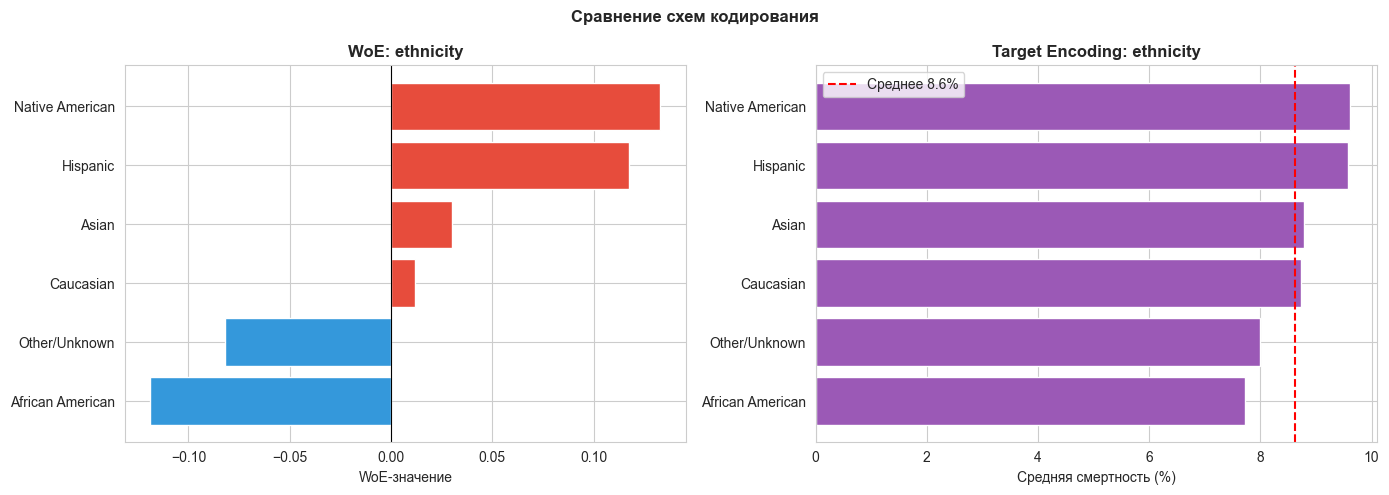

In [15]:
# Сравнение WoE vs Target Encoding на одном столбце
compare_col = cat_cols_in_X[0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# WoE
woe_vals = woe_summary[compare_col].sort_values()
colors_w = ['#e74c3c' if v > 0 else '#3498db' for v in woe_vals.values]
axes[0].barh(woe_vals.index.astype(str), woe_vals.values, color=colors_w)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title(f'WoE: {compare_col}', fontweight='bold')
axes[0].set_xlabel('WoE-значение')

# Target
tgt_vals = pd.DataFrame({'cat': X_train[compare_col], 'val': X_train_target[compare_col]})\
             .groupby('cat')['val'].mean().sort_values()
axes[1].barh(tgt_vals.index.astype(str), tgt_vals.values * 100, color='#9b59b6')
axes[1].axvline(y_train.mean() * 100, color='red', linestyle='--', label=f'Среднее {y_train.mean()*100:.1f}%')
axes[1].set_title(f'Target Encoding: {compare_col}', fontweight='bold')
axes[1].set_xlabel('Средняя смертность (%)')
axes[1].legend()

plt.suptitle('Сравнение схем кодирования', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Финальная проверка

In [16]:
# Замена inf на NaN и заполнение медианой (WoE может давать inf при нулевых частотах)
for name, Xd in [('X_train_woe', X_train_woe), ('X_test_woe', X_test_woe),
                  ('X_train_target', X_train_target), ('X_test_target', X_test_target)]:
    Xd.replace([np.inf, -np.inf], np.nan, inplace=True)
    num_in = Xd.select_dtypes(include=np.number).columns
    Xd[num_in] = Xd[num_in].fillna(Xd[num_in].median())

print('Финальная проверка:')
print(f'{"Датасет":<22} {"Shape":<18} {"Пропуски":<12} {"Inf"}')
print('-' * 60)
for name, Xd in [('X_train_woe', X_train_woe), ('X_test_woe', X_test_woe),
                  ('X_train_target', X_train_target), ('X_test_target', X_test_target)]:
    n_miss = Xd.isnull().sum().sum()
    n_inf  = np.isinf(Xd.select_dtypes(include=np.number)).sum().sum()
    print(f'{name:<22} {str(Xd.shape):<18} {n_miss:<12} {n_inf}')

Финальная проверка:
Датасет                Shape              Пропуски     Inf
------------------------------------------------------------
X_train_woe            (73370, 119)       0            0
X_test_woe             (18343, 119)       0            0
X_train_target         (73370, 119)       0            0
X_test_target          (18343, 119)       0            0


## 11. Сохранение данных

In [17]:
X_train_woe.to_parquet('X_train_woe.parquet',       index=False)
X_test_woe.to_parquet('X_test_woe.parquet',         index=False)
X_train_target.to_parquet('X_train_target.parquet', index=False)
X_test_target.to_parquet('X_test_target.parquet',   index=False)
y_train.to_frame().to_parquet('y_train.parquet',    index=False)
y_test.to_frame().to_parquet('y_test.parquet',      index=False)

print('Файлы сохранены:')
for fname in ['X_train_woe.parquet', 'X_test_woe.parquet',
              'X_train_target.parquet', 'X_test_target.parquet',
              'y_train.parquet', 'y_test.parquet']:
    print(f'  checkmark {fname}')

Файлы сохранены:
  checkmark X_train_woe.parquet
  checkmark X_test_woe.parquet
  checkmark X_train_target.parquet
  checkmark X_test_target.parquet
  checkmark y_train.parquet
  checkmark y_test.parquet


## 12. Итоговая сводка

In [19]:
print('Итог по подготовке данных')

steps = [
    f'Удалено {len(drop_cols)} столбцов: идентификаторы, leakage, мусор',
    f'Добавлено {len(flag_cols)} флагов пропусков (_was_missing)',
    'Пропуски заполнены: медиана (числовые), мода (категориальные)',
    f'Клиппинг по клиническим границам: {len(clinical_bounds)} столбцов',
    f'Train/Test split 80/20 со стратификацией',
    f'RobustScaler: {len(num_cols_in_X)} числовых признаков',
    f'WoE-кодирование: {len(cat_cols_in_X)} категориальных признаков',
    f'Target-кодирование: {len(cat_cols_in_X)} категориальных признаков',
]
for i, s in enumerate(steps, 1):
    print(f'  {i}. {s}')
print(f'\nИтоговые матрицы: {X_train_woe.shape[1]} признаков')
print(f'  Train: {X_train_woe.shape[0]:,} строк')
print(f'  Test:  {X_test_woe.shape[0]:,} строк')
print(f'\nСохранено 6 .parquet файлов для построения моделей')

Итог по подготовке данных
  1. Удалено 7 столбцов: идентификаторы, leakage, мусор
  2. Добавлено 42 флагов пропусков (_was_missing)
  3. Пропуски заполнены: медиана (числовые), мода (категориальные)
  4. Клиппинг по клиническим границам: 42 столбцов
  5. Train/Test split 80/20 со стратификацией
  6. RobustScaler: 56 числовых признаков
  7. WoE-кодирование: 7 категориальных признаков
  8. Target-кодирование: 7 категориальных признаков

Итоговые матрицы: 119 признаков
  Train: 73,370 строк
  Test:  18,343 строк

Сохранено 6 .parquet файлов для построения моделей
